### Imports 

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yaml

from life_expectancy.data.preprocessing import build_processed_dataset
from life_expectancy.features.feature_engineering import prepare_numeric_model_frame

plt.rcParams.update(
    {
        "font.size": 14,
        "axes.titlesize": 18,
        "axes.labelsize": 16,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 12,
    }
)

sns.set_style("whitegrid")

### Verifying Project Root

In [2]:
from life_expectancy.data.utils import resolve_project_path


PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
CONFIG_PATH = PROJECT_ROOT / "configs" / "default.yaml"

with CONFIG_PATH.open("r", encoding="utf-8") as file:
    config = yaml.safe_load(file)

config["project"]["root"] = str(PROJECT_ROOT)

PROCESSED = resolve_project_path(config, "data/processed")
PROCESSED.mkdir(parents=True, exist_ok=True)
RANDOM_SEED = config.get("random_seed", 42)
TARGET = config["features"].get("target_col", "life_expectancy")
YEAR_COL = config["features"].get("year_col", "year")

print("Project root:", PROJECT_ROOT)
print("Processed dir:", PROCESSED)
print("Target:", TARGET)

Project root: /Users/aleksia/Desktop/RND4IMPACT Projects/life-expectancy-analysis
Processed dir: /Users/aleksia/Desktop/RND4IMPACT Projects/life-expectancy-analysis/data/processed
Target: life_expectancy


In [3]:
panel, preprocessing_summary = build_processed_dataset(config)

panel[YEAR_COL] = pd.to_numeric(panel[YEAR_COL], errors="raise").astype(int)
panel = panel.dropna(subset=[TARGET]).copy()

metrics_path = PROJECT_ROOT / "outputs" / "metrics" / "baseline_results.csv"
df_metrics = pd.read_csv(metrics_path)

panel.head(), panel.shape

(       country  year      status  life_expectancy_who  adult_mortality  \
 0  Afghanistan  2015  Developing                 65.0            263.0   
 1  Afghanistan  2014  Developing                 59.9            271.0   
 2  Afghanistan  2013  Developing                 59.9            268.0   
 3  Afghanistan  2012  Developing                 59.5            272.0   
 4  Afghanistan  2011  Developing                 59.2            275.0   
 
    infant_deaths  alcohol  percentage_expenditure  hepatitis_b  measles  ...  \
 0             62     0.01               71.279624         65.0      100  ...   
 1             64     0.01               73.523582         62.0      100  ...   
 2             66     0.01               73.219243         64.0      100  ...   
 3             69     0.01               78.184215         67.0      100  ...   
 4             71     0.01                7.097109         68.0      100  ...   
 
            co2  health_expenditure_percent  education_expen

## Region trend plot (median + IQR band)

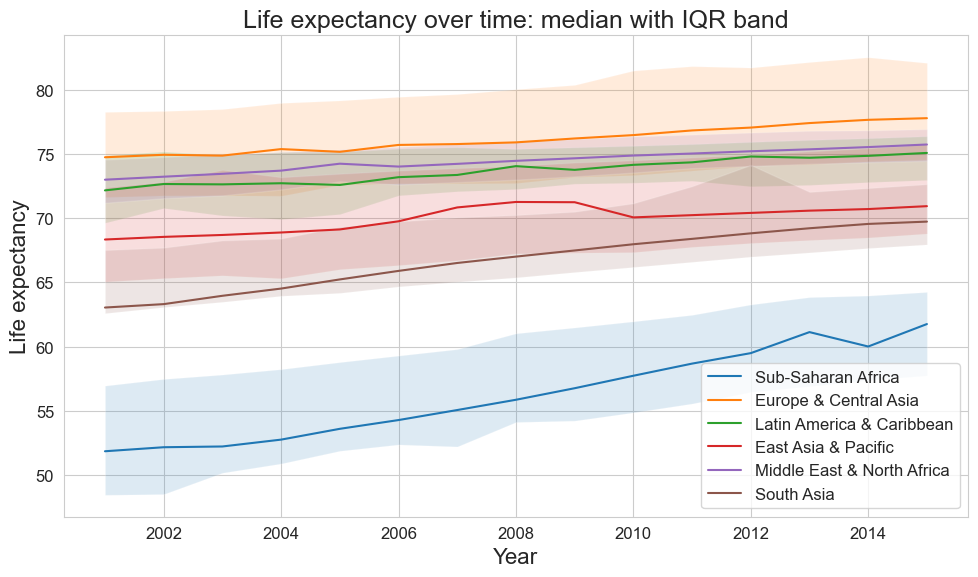

In [4]:
if "region" in panel.columns:
    grouped = panel.groupby(["region", YEAR_COL])[TARGET]

    trend = grouped.agg(
        median="median",
        q25=lambda values: values.quantile(0.25),
        q75=lambda values: values.quantile(0.75),
        n="size",
    ).reset_index()

    top_regions = panel["region"].value_counts().head(6).index.tolist()
    plot_df = trend[trend["region"].isin(top_regions)].copy()

    plt.figure(figsize=(10, 6))

    for region in top_regions:
        sub = plot_df[plot_df["region"] == region]
        plt.plot(sub[YEAR_COL], sub["median"], label=region)
        plt.fill_between(
            sub[YEAR_COL],
            sub["q25"],
            sub["q75"],
            alpha=0.15,
        )

    plt.title("Life expectancy over time: median with IQR band")
    plt.xlabel("Year")
    plt.ylabel("Life expectancy")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("region column not available")

The improvement over time indicates global health development, but persistent regional gaps show structural inequality in healthcare access, sanitation, and economic conditions.

## Region Boxplot

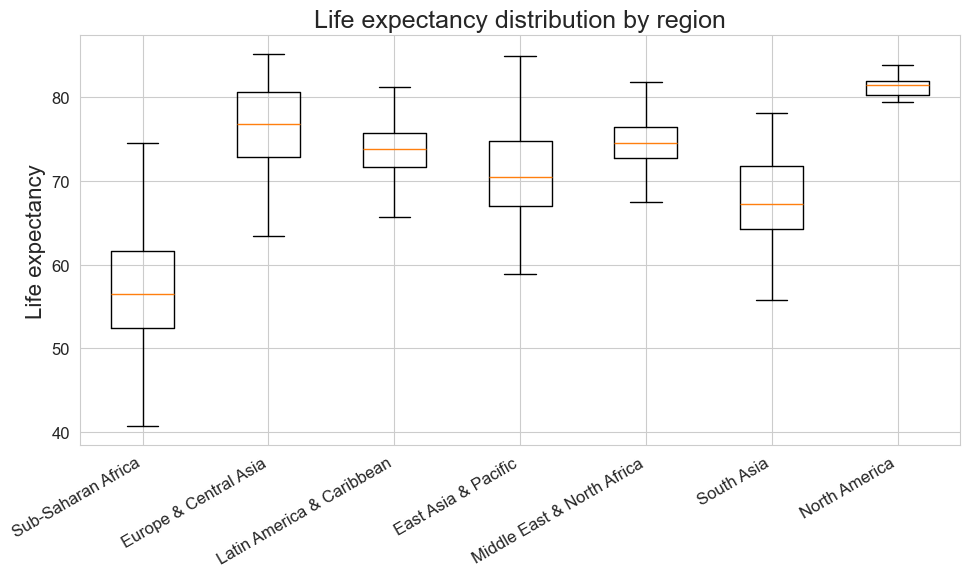

In [5]:
if "region" in panel.columns:
    top_regions = panel["region"].value_counts().head(8).index.tolist()
    sub = panel[panel["region"].isin(top_regions)].copy()

    data = [
        sub.loc[sub["region"] == region, TARGET].dropna().values
        for region in top_regions
    ]

    plt.figure(figsize=(10, 6))
    plt.boxplot(
        data,
        tick_labels=top_regions,
        vert=True,
        showfliers=False,
    )
    plt.xticks(rotation=30, ha="right")
    plt.title("Life expectancy distribution by region")
    plt.ylabel("Life expectancy")
    plt.tight_layout()
    plt.show()
else:
    print("region column not available")

### Sub-Saharan Africa:

- lowest median
- largest spread

*Meaning*:
Some countries doing okay, others extremely poor health conditions.

### Europe:

- high median
- tight distribution

*Meaning*:
Consistent healthcare systems and infrastructure.

## GDP vs Life Expectancy (log)

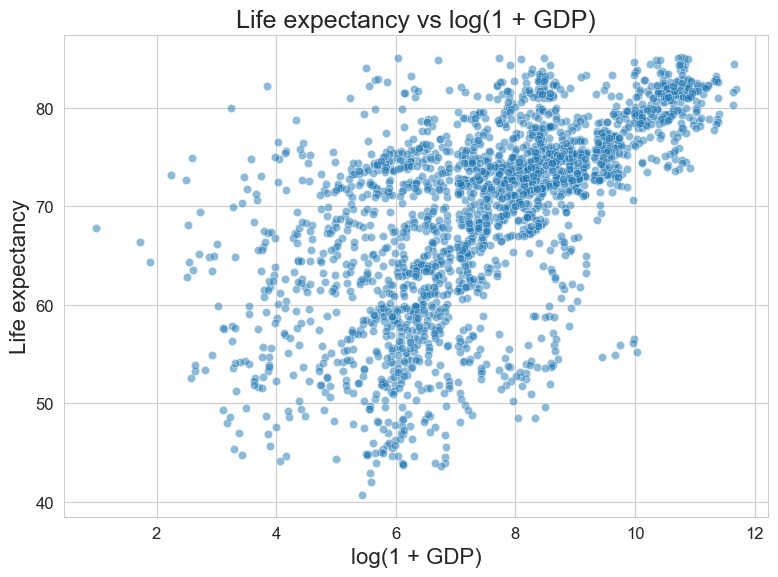

In [6]:
if "gdp" in panel.columns:
    sub = panel.dropna(subset=["gdp", TARGET]).copy()
    sub["log_gdp"] = np.log1p(pd.to_numeric(sub["gdp"], errors="coerce").clip(0))

    plt.figure(figsize=(8, 6))
    sns.scatterplot(
        data=sub,
        x="log_gdp",
        y=TARGET,
        alpha=0.5,
    )
    plt.title("Life expectancy vs log(1 + GDP)")
    plt.xlabel("log(1 + GDP)")
    plt.ylabel("Life expectancy")
    plt.tight_layout()
    plt.show()
else:
    print("gdp column not available")

First off, GDP is extremely skewed, so we log transform to compress scale so relationships become visible. This is one of the most famous relationship in development economics where wealthier countries live longer. However we can see from this plot that this relationship is not linear. At low GDP small income increases give huge life expectancy gains. At high GDP we see a plateau. After a certain level of wealth, additional money does NOT translate into health improvement.

## Schooling vs Life Expectancy

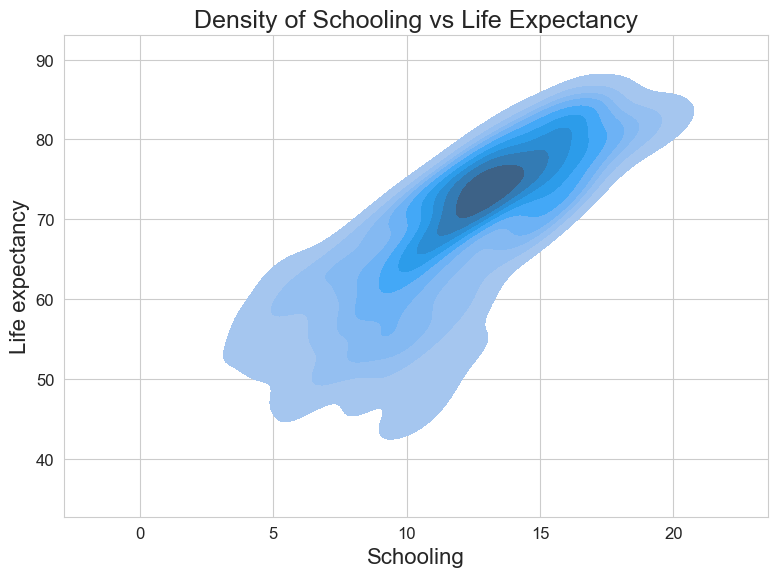

In [7]:
if "schooling" in panel.columns:
    sub = panel.dropna(subset=["schooling", TARGET]).copy()

    plt.figure(figsize=(8, 6))
    sns.kdeplot(
        data=sub,
        x="schooling",
        y=TARGET,
        fill=True,
    )
    plt.title("Density of Schooling vs Life Expectancy")
    plt.xlabel("Schooling")
    plt.ylabel("Life expectancy")
    plt.tight_layout()
    plt.show()
else:
    print("schooling column not available")

There is a clear positive relationship. Education affects:

- hygiene
- health awareness
- fertility rates
- healthcare usage
- nutrition

We can see how education can predict life expectancy better than GDP in development research.

## Correlation Heatmap (reduced predictors)

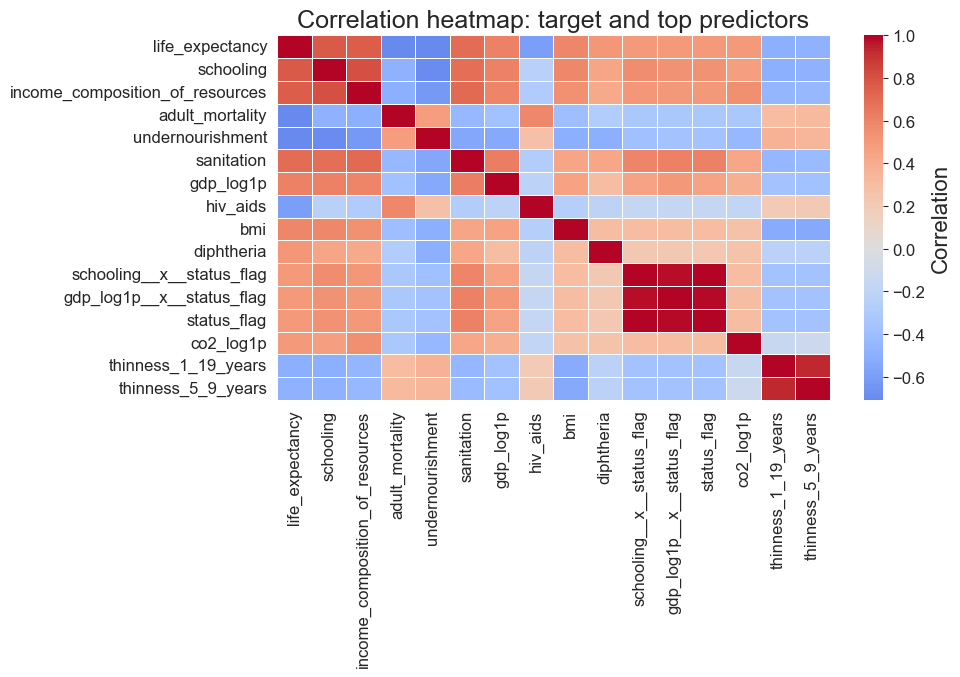

In [8]:
model_df = prepare_numeric_model_frame(panel, config)

drop_cols = [
    col
    for col in ["life_expectancy_who", "life_expectancy_wb"]
    if col in model_df.columns
]

num_df = model_df.drop(columns=drop_cols, errors="ignore").select_dtypes(
    include=["number"]
)

corr_with_target = num_df.corr(numeric_only=True)[TARGET].sort_values(
    key=lambda values: values.abs(),
    ascending=False,
)

top_features = [
    col for col in corr_with_target.index.tolist()
    if col != TARGET
][:15]

heat_cols = [TARGET, *top_features]
corr_mat = num_df[heat_cols].corr(numeric_only=True)

plt.figure(figsize=(10, 7))

sns.heatmap(
    corr_mat,
    cmap="coolwarm",
    center=0,
    annot=False,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"label": "Correlation"},
)

plt.title("Correlation heatmap: target and top predictors")
plt.tight_layout()
plt.show()

### Strong positive correlations:

- schooling
- income composition
- sanitation

### Strong negative correlations:

- adult mortality
- HIV/AIDS
- undernourishment

## RMSE/MAE/R² by model (per split)

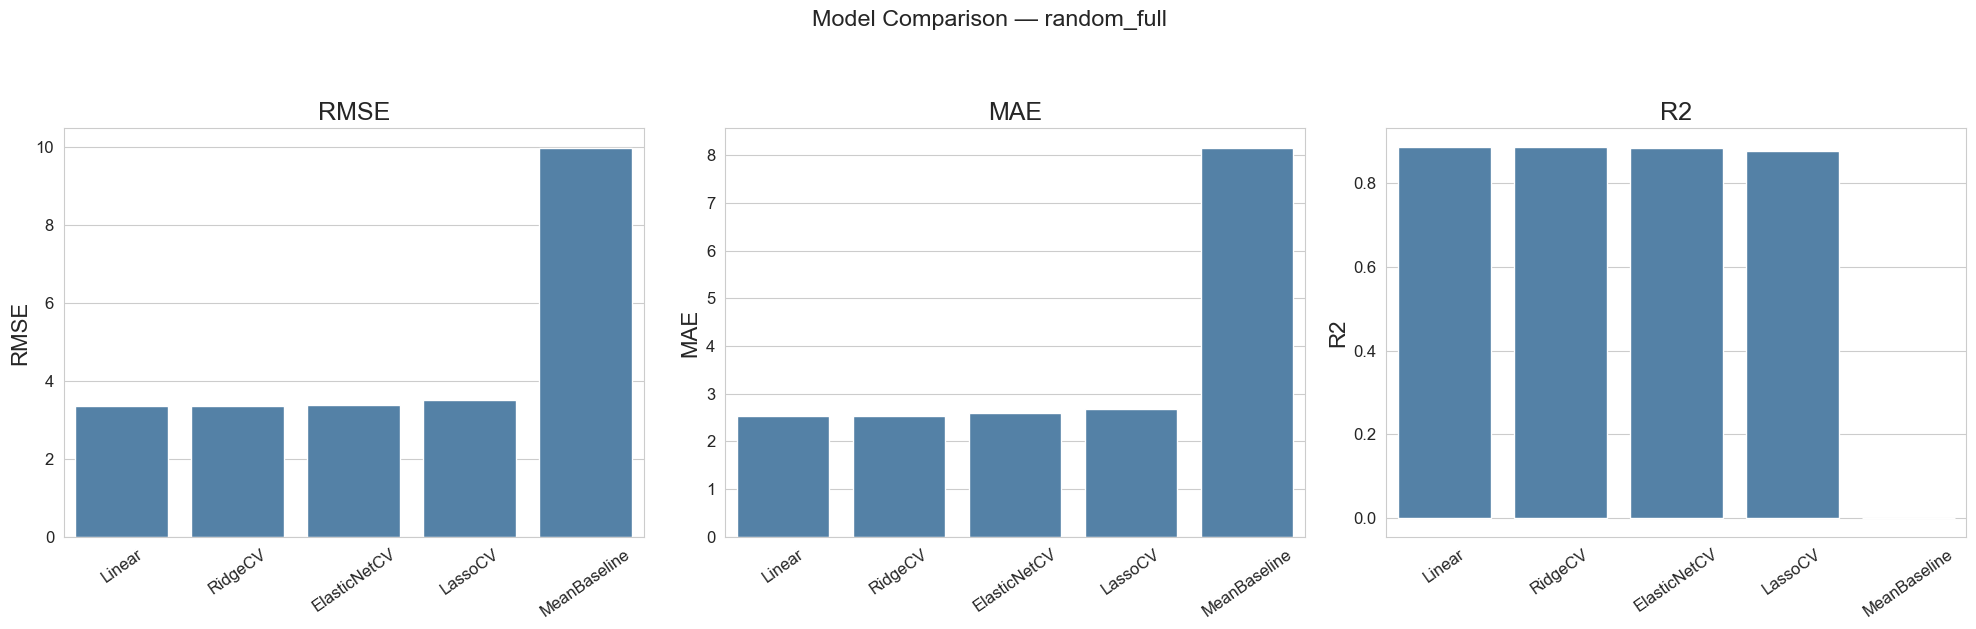

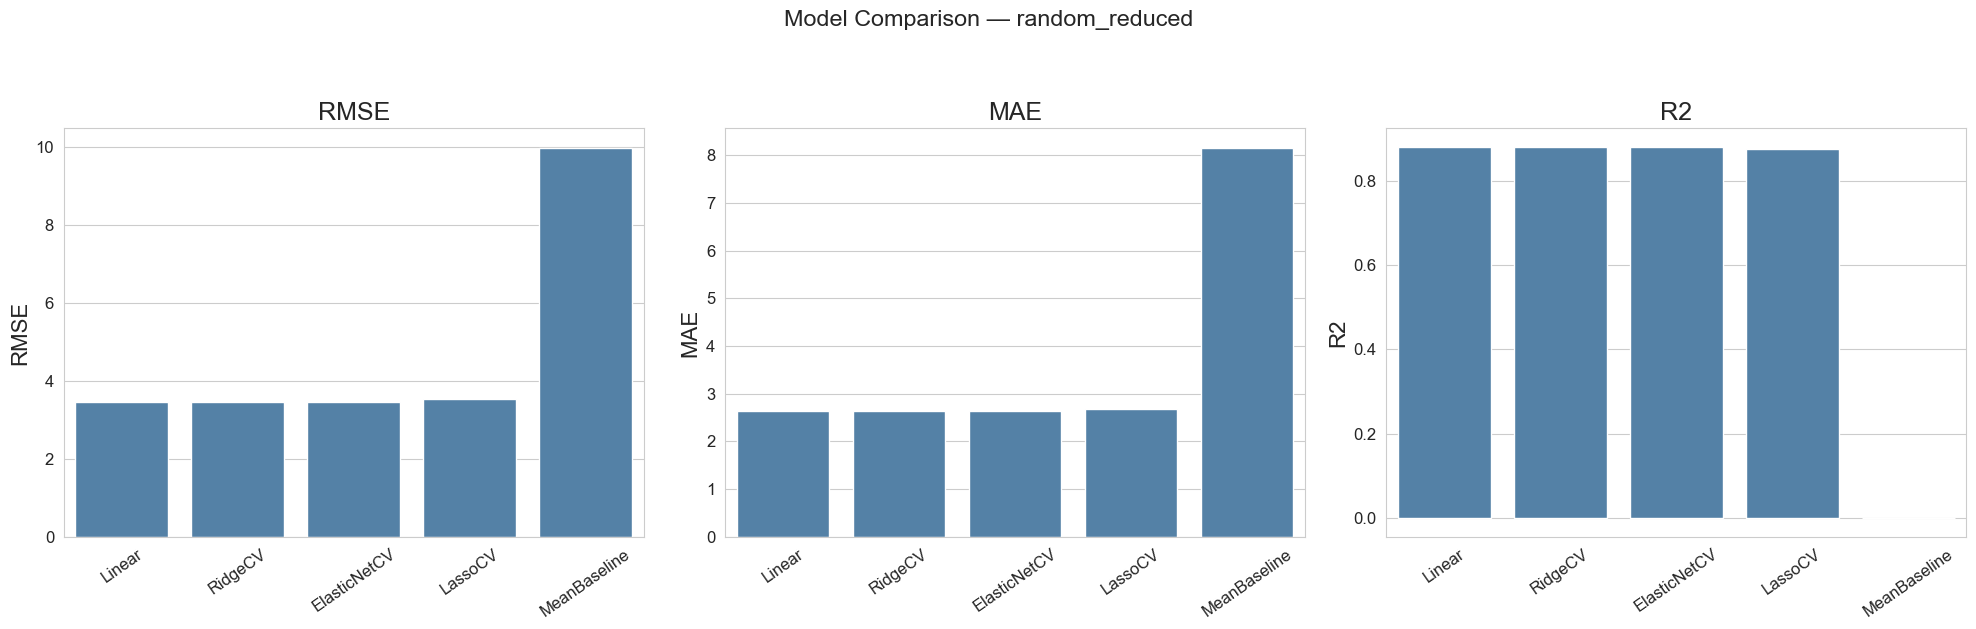

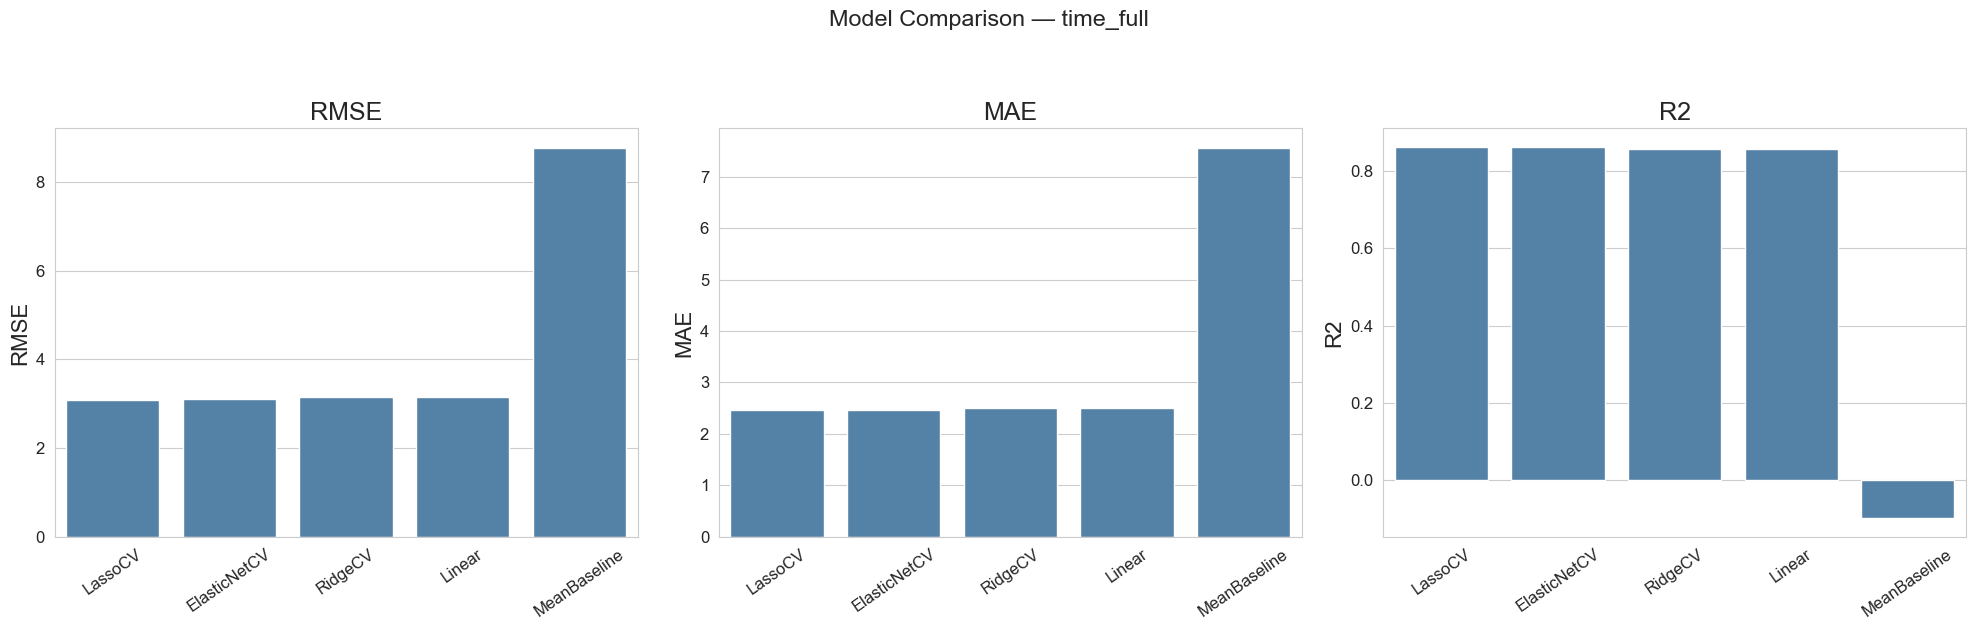

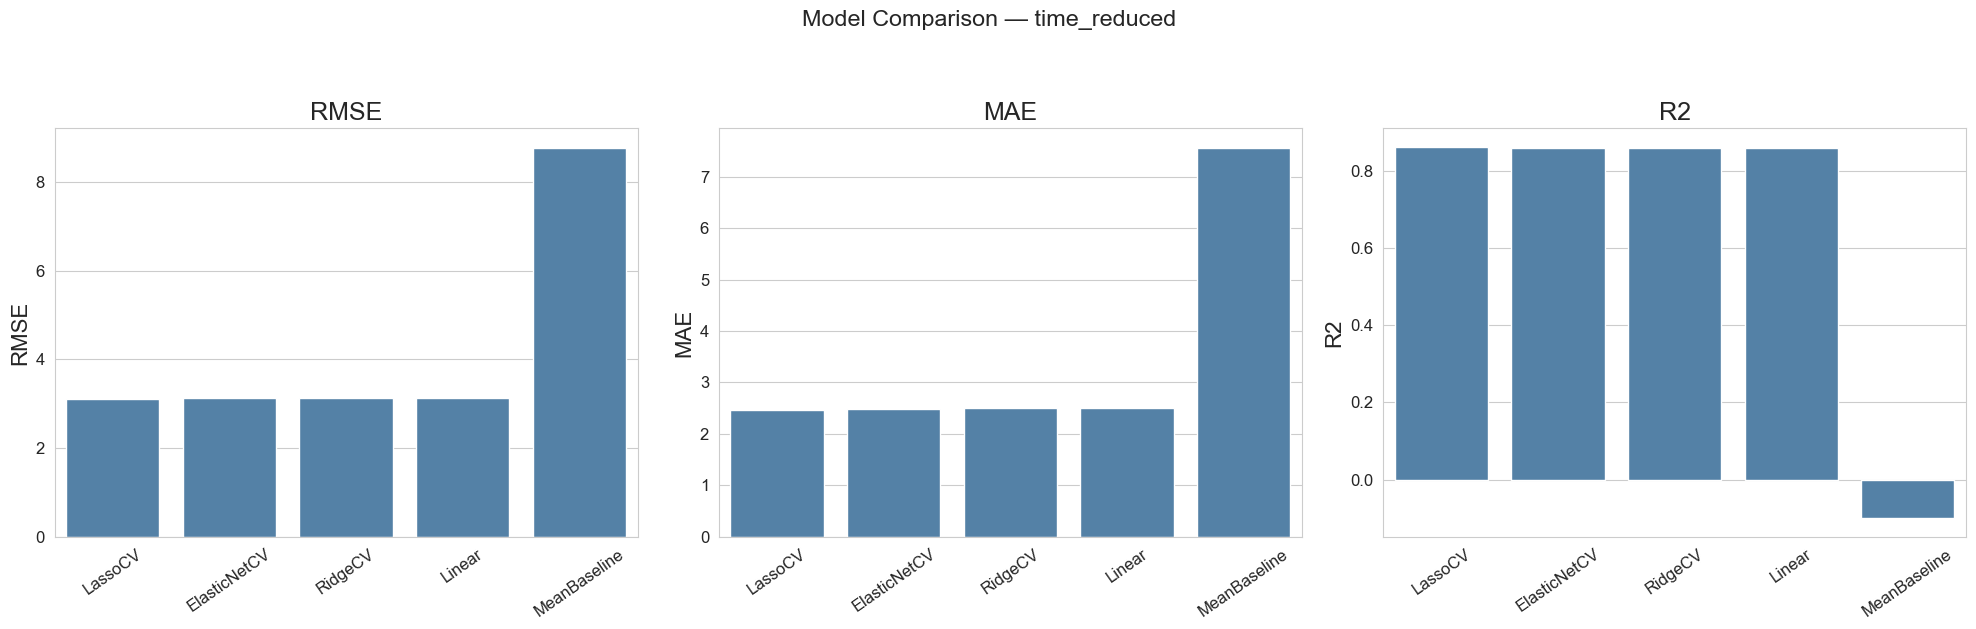

In [9]:
metrics = ["rmse", "mae", "r2"]
splits = sorted(df_metrics["split_name"].unique())

for split in splits:
    sub = df_metrics[df_metrics["split_name"] == split].copy()
    sub = sub.sort_values("rmse")

    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    fig.suptitle(f"Model Comparison — {split}", y=1.05)

    for ax, metric in zip(axes, ["rmse", "mae", "r2"], strict=False):
        sns.barplot(
            data=sub,
            x="model_name",
            y=metric,
            color="steelblue",
            ax=ax,
        )

        ax.set_title(metric.upper())
        ax.set_xlabel("")
        ax.set_ylabel(metric.upper())
        ax.tick_params(axis="x", rotation=35)

    plt.tight_layout()
    plt.show()

## Heatmap: Model ranking across splits

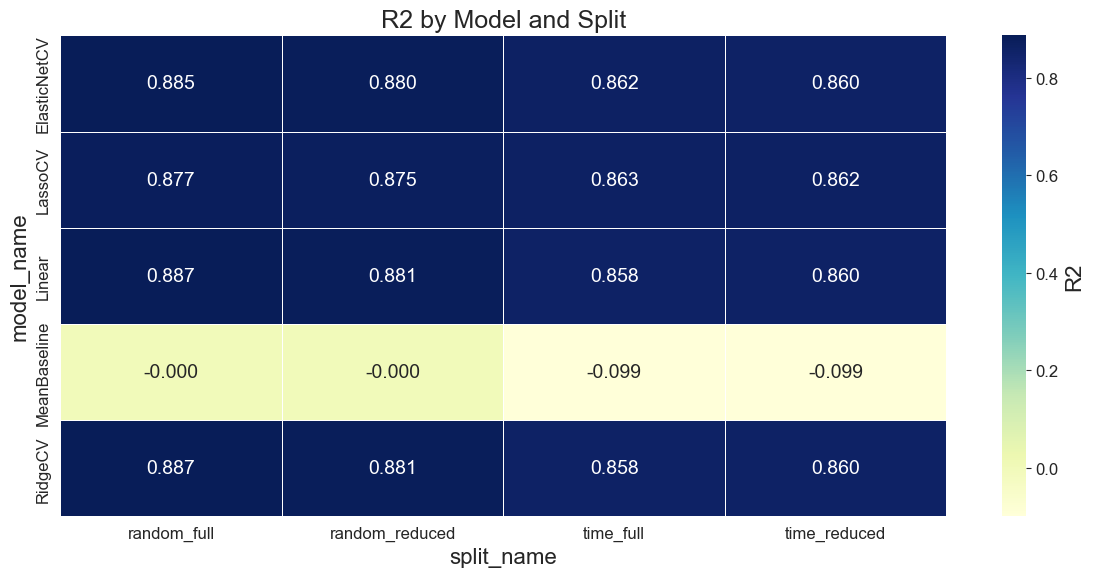

In [10]:
rank_metric = "r2"

pivot = df_metrics.pivot(
    index="model_name",
    columns="split_name",
    values=rank_metric,
)

plt.figure(figsize=(12, 6))

sns.heatmap(
    pivot,
    annot=True,
    fmt=".3f",
    cmap="YlGnBu",
    linewidths=0.5,
    cbar_kws={"label": rank_metric.upper()},
)

plt.title(f"{rank_metric.upper()} by Model and Split")
plt.tight_layout()
plt.show()

## “Generalization gap” plot: Time split vs Random split

,model_name,rmse_random,rmse_time,delta_rmse
0,Linear,3.353319,3.156877,-0.196441
1,RidgeCV,3.353763,3.152573,-0.201190
2,ElasticNetCV,3.393719,3.106721,-0.286998
3,LassoCV,3.510327,3.093671,-0.416655
4,MeanBaseline,9.992520,8.777449,-1.215072


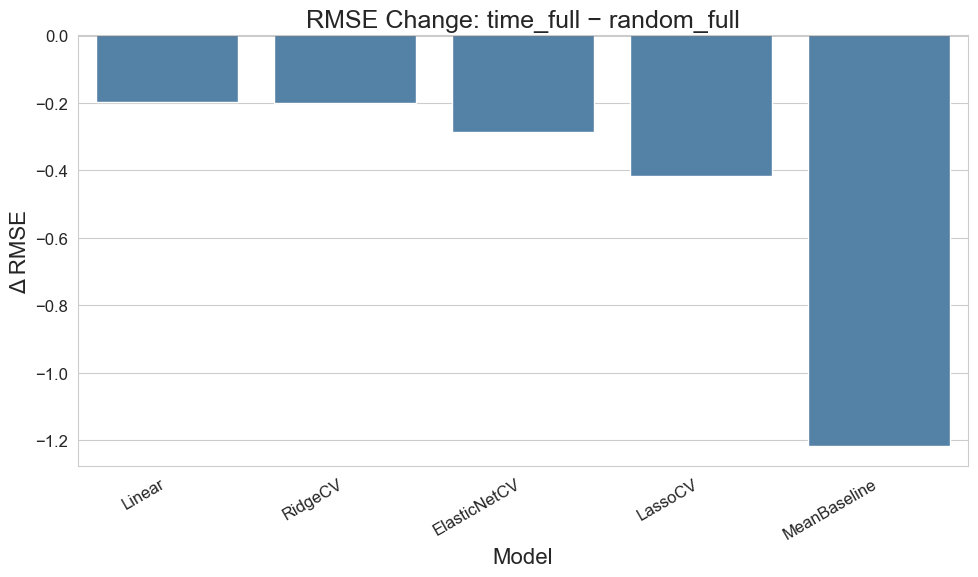

In [12]:
split_a = "random_full"
split_b = "time_full"

random_results = df_metrics[df_metrics["split_name"] == split_a][
    ["model_name", "rmse"]
].rename(columns={"rmse": "rmse_random"})

time_results = df_metrics[df_metrics["split_name"] == split_b][
    ["model_name", "rmse"]
].rename(columns={"rmse": "rmse_time"})

gap_df = random_results.merge(time_results, on="model_name", how="inner")
gap_df["delta_rmse"] = gap_df["rmse_time"] - gap_df["rmse_random"]
gap_df = gap_df.sort_values("delta_rmse", ascending=False)

display(gap_df)

plt.figure(figsize=(10, 6))

if gap_df["delta_rmse"].abs().max() == 0:
    plt.text(
        0.5,
        0.5,
        "No RMSE difference between selected splits",
        ha="center",
        va="center",
        transform=plt.gca().transAxes,
    )
    plt.ylim(-0.05, 0.05)
else:
    sns.barplot(
        data=gap_df,
        x="model_name",
        y="delta_rmse",
        color="steelblue",
    )

plt.axhline(0, color="black", linewidth=1)
plt.title(f"RMSE Change: {split_b} − {split_a}")
plt.xlabel("Model")
plt.ylabel("Δ RMSE")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()